# 05. EfficientNetB0 con Transfer Learning

En este notebook se entrena una arquitectura EfficientNetB0 preentrenada en ImageNet para clasificar imágenes de TC pulmonar en tres clases: `benign`, `malignant` y `normal`.

El objetivo es evaluar el rendimiento de una arquitectura eficiente basada en escalado compuesto, utilizando las mismas particiones de entrenamiento, validación y prueba que en el resto de modelos.

El entrenamiento se realiza en dos fases:

1. Entrenamiento de una cabeza clasificadora con la base EfficientNetB0 congelada.
2. Fine-tuning parcial de las últimas capas de la red.

Los resultados obtenidos se guardarán para su posterior comparación con MobileNetV2 y ResNet50.

## 0. Configuración inicial

Se importan las librerías necesarias, se fija la semilla de reproducibilidad y se definen los parámetros principales del experimento: tamaño de entrada, batch size, número de épocas y clases del problema.

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess_input

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

EPOCHS_HEAD = 15
EPOCHS_FINE = 20

CLASSES = ["benign", "malignant", "normal"]

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
GPU disponible: []


## 1. Localización de archivos procesados

Se localizan los archivos generados durante el análisis exploratorio del dataset. Este notebook reutiliza las particiones `train.csv`, `val.csv` y `test.csv`.

No se realiza una nueva división del dataset, ya que todos los modelos deben evaluarse sobre las mismas particiones para que la comparación sea válida.

In [2]:
possible_processed_paths = [
    Path("/kaggle/working/processed"),
    Path("/content/processed"),
    Path("processed"),
    Path("../processed"),
    Path("../data/processed"),
    Path("data/processed")
]

processed_path = None

for candidate_path in possible_processed_paths:
    if (
        (candidate_path / "train.csv").exists()
        and (candidate_path / "val.csv").exists()
        and (candidate_path / "test.csv").exists()
    ):
        processed_path = candidate_path
        break

if processed_path is None:
    raise FileNotFoundError(
        "No se encontraron train.csv, val.csv y test.csv. "
        "Ejecuta primero el notebook 01_eda_dataset.ipynb."
    )

if Path("/kaggle/working").exists():
    output_path = Path("/kaggle/working/efficientnetb0_outputs")
elif Path("/content").exists():
    output_path = Path("/content/efficientnetb0_outputs")
else:
    output_path = Path("../outputs/efficientnetb0_outputs")

models_path = output_path / "models"
figures_path = output_path / "figures"
metrics_path = output_path / "metrics"

for path in [output_path, models_path, figures_path, metrics_path]:
    path.mkdir(parents=True, exist_ok=True)

print("Carpeta processed:", processed_path)
print("Carpeta de salida:", output_path)

Carpeta processed: ..\data\processed
Carpeta de salida: ..\outputs\efficientnetb0_outputs


## 2. Carga de particiones

Se cargan los conjuntos de entrenamiento, validación y prueba. Estas particiones proceden del EDA y son comunes para todos los modelos evaluados en el proyecto.

In [3]:
train_df = pd.read_csv(processed_path / "train.csv")
val_df = pd.read_csv(processed_path / "val.csv")
test_df = pd.read_csv(processed_path / "test.csv")

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nDistribución train:")
print(train_df["class"].value_counts())

print("\nDistribución validation:")
print(val_df["class"].value_counts())

print("\nDistribución test:")
print(test_df["class"].value_counts())

train_df.head()

Train: 737
Validation: 158
Test: 159

Distribución train:
class
malignant    383
normal       283
benign        71
Name: count, dtype: int64

Distribución validation:
class
malignant    82
normal       61
benign       15
Name: count, dtype: int64

Distribución test:
class
malignant    82
normal       61
benign       16
Name: count, dtype: int64


,path,filename,original_class,class,width,height,mode,file_hash
0,C:\Users\Usuario\.cache\kagglehub\datasets\adi...,Normal case (115).jpg,Normal cases,normal,512,512,RGB,a9128a9a910537098e33c2a3350a8c7c
1,C:\Users\Usuario\.cache\kagglehub\datasets\adi...,Malignant case (207).jpg,Malignant cases,malignant,801,512,RGB,85225f8c4826bbd56c64ca902b28d89f
2,C:\Users\Usuario\.cache\kagglehub\datasets\adi...,Malignant case (234).jpg,Malignant cases,malignant,623,512,RGB,643b013da4be76ace9306e9bb73495e8
3,C:\Users\Usuario\.cache\kagglehub\datasets\adi...,Normal case (301).jpg,Normal cases,normal,512,512,RGB,baf4ec74ec73cc079bf22b86602b2e5f
4,C:\Users\Usuario\.cache\kagglehub\datasets\adi...,Malignant case (392).jpg,Malignant cases,malignant,512,512,RGB,a79dc4739b43b614e5e96826f3f642ae


In [4]:
for split_name, split_df in {
    "train": train_df,
    "validation": val_df,
    "test": test_df
}.items():
    missing_paths = split_df[~split_df["path"].apply(lambda x: Path(x).exists())]
    print(f"{split_name} - rutas inexistentes: {len(missing_paths)}")

train - rutas inexistentes: 0
validation - rutas inexistentes: 0
test - rutas inexistentes: 0


## 3. Generadores de imágenes

Se crean los generadores de imágenes específicos para EfficientNetB0. Las imágenes se redimensionan a 224x224 píxeles y se procesan mediante la función `preprocess_input` propia de EfficientNet.

En el conjunto de entrenamiento se aplica aumentación moderada para reducir el sobreajuste. En validación y test no se aplica aumentación, únicamente el preprocesamiento necesario.

In [5]:
train_datagen = ImageDataGenerator(
    preprocessing_function=efficientnet_preprocess_input,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=efficientnet_preprocess_input
)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="path",
    y_col="class",
    classes=CLASSES,
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_gen = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="path",
    y_col="class",
    classes=CLASSES,
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="path",
    y_col="class",
    classes=CLASSES,
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Índices de clase:", train_gen.class_indices)

Found 737 validated image filenames belonging to 3 classes.
Found 158 validated image filenames belonging to 3 classes.
Found 159 validated image filenames belonging to 3 classes.
Índices de clase: {'benign': 0, 'malignant': 1, 'normal': 2}


## 4. Cálculo de pesos de clase

Debido al desbalanceo entre clases, especialmente en la clase `benign`, se calculan pesos de clase usando únicamente el conjunto de entrenamiento.

Estos pesos permiten que los errores cometidos en clases minoritarias tengan mayor impacto durante el proceso de aprendizaje.

In [6]:
class_names = np.array(CLASSES)

weights = compute_class_weight(
    class_weight="balanced",
    classes=class_names,
    y=train_df["class"]
)

class_weight_by_name = dict(zip(class_names, weights))

class_weight = {
    train_gen.class_indices[class_name]: weight
    for class_name, weight in class_weight_by_name.items()
}

print("Pesos por clase:")
print(class_weight_by_name)

print("\nPesos por índice Keras:")
print(class_weight)

Pesos por clase:
{np.str_('benign'): np.float64(3.460093896713615), np.str_('malignant'): np.float64(0.6414273281114012), np.str_('normal'): np.float64(0.8680800942285041)}

Pesos por índice Keras:
{0: np.float64(3.460093896713615), 1: np.float64(0.6414273281114012), 2: np.float64(0.8680800942285041)}


## 5. Definición del modelo EfficientNetB0

Se utiliza EfficientNetB0 como base convolucional preentrenada en ImageNet. La capa superior original se elimina y se añade una cabeza clasificadora adaptada a las tres clases del problema.

En esta primera fase, la base EfficientNetB0 permanece congelada y solo se entrena la nueva cabeza clasificadora.

In [7]:
def build_efficientnetb0_model(input_shape=(224, 224, 3), num_classes=3):
    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )

    base_model.trainable = False

    inputs = layers.Input(shape=input_shape)

    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model, base_model


efficientnet_model, efficientnet_base = build_efficientnetb0_model(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=len(CLASSES)
)

efficientnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 35s 2us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             771 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,383,398 (16.72 MB)

 Trainable params: 331,267 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## 6. Entrenamiento de la cabeza clasificadora

En esta fase se entrena únicamente la cabeza clasificadora añadida sobre EfficientNetB0. La base convolucional permanece congelada para aprovechar las características generales aprendidas durante el preentrenamiento.

Se utilizan callbacks para guardar el mejor modelo, reducir el learning rate cuando la validación se estanca y detener el entrenamiento si no se observa mejora.

In [8]:
efficientnet_head_checkpoint_path = models_path / "efficientnetb0_head_best.keras"

head_callbacks = [
    callbacks.ModelCheckpoint(
        filepath=efficientnet_head_checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    )
]

history_head = efficientnet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_HEAD,
    callbacks=head_callbacks,
    class_weight=class_weight,
    verbose=1
)

Epoch 1/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.4787 - loss: 1.8676
Epoch 1: val_loss improved from None to 0.65890, saving model to ..\outputs\efficientnetb0_outputs\models\efficientnetb0_head_best.keras

Epoch 1: finished saving model to ..\outputs\efficientnetb0_outputs\models\efficientnetb0_head_best.keras
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 315ms/step - accuracy: 0.5346 - loss: 1.7073 - val_accuracy: 0.8418 - val_loss: 0.6589 - learning_rate: 1.0000e-04
Epoch 2/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.6844 - loss: 1.1597
Epoch 2: val_loss improved from 0.65890 to 0.58784, saving model to ..\outputs\efficientnetb0_outputs\models\efficientnetb0_head_best.keras

Epoch 2: finished saving model to ..\outputs\efficientnetb0_outputs\models\efficientnetb0_head_best.keras
47/47 ━━━━━━━━━━━━━━━━━━━━ 13s 270ms/step - accuracy: 0.6716 - loss: 1.1230 - val_accuracy: 0.7658 - val_loss: 0.5878 - learning_rate: 1.0000e-04
Epoch 3/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 225m

In [9]:
efficientnet_base.trainable = True

for layer in efficientnet_base.layers[:-30]:
    layer.trainable = False

for layer in efficientnet_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

efficientnet_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

trainable_layers = sum([1 for layer in efficientnet_base.layers if layer.trainable])
print("Capas entrenables en la base EfficientNetB0:", trainable_layers)

Capas entrenables en la base EfficientNetB0: 23


## 7. Fine-tuning del modelo

Tras entrenar la cabeza clasificadora, se desbloquean las últimas capas de EfficientNetB0 para adaptar parcialmente el modelo al dominio de las imágenes de TC pulmonar.

El fine-tuning se realiza con un learning rate bajo para evitar modificar de forma brusca los pesos preentrenados.ora.

In [10]:
efficientnet_finetune_checkpoint_path = models_path / "efficientnetb0_finetuned_best.keras"

finetune_callbacks = [
    callbacks.ModelCheckpoint(
        filepath=efficientnet_finetune_checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-8,
        verbose=1
    ),
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    )
]

history_fine = efficientnet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FINE,
    callbacks=finetune_callbacks,
    class_weight=class_weight,
    verbose=1
)

Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.7938 - loss: 0.6852
Epoch 1: val_loss improved from None to 0.45009, saving model to ..\outputs\efficientnetb0_outputs\models\efficientnetb0_finetuned_best.keras

Epoch 1: finished saving model to ..\outputs\efficientnetb0_outputs\models\efficientnetb0_finetuned_best.keras
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 322ms/step - accuracy: 0.7815 - loss: 0.6598 - val_accuracy: 0.8228 - val_loss: 0.4501 - learning_rate: 1.0000e-05
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.8157 - loss: 0.5597
Epoch 2: val_loss improved from 0.45009 to 0.44599, saving model to ..\outputs\efficientnetb0_outputs\models\efficientnetb0_finetuned_best.keras

Epoch 2: finished saving model to ..\outputs\efficientnetb0_outputs\models\efficientnetb0_finetuned_best.keras
47/47 ━━━━━━━━━━━━━━━━━━━━ 13s 279ms/step - accuracy: 0.8046 - loss: 0.6749 - val_accuracy: 0.8354 - val_loss: 0.4460 - learning_rate: 1.0000e-05
Epoch 3/20
47/47 ━━━━━━━━

In [11]:
history_head_df = pd.DataFrame(history_head.history)
history_fine_df = pd.DataFrame(history_fine.history)

history_head_df["phase"] = "head"
history_fine_df["phase"] = "fine_tuning"

history_efficientnet_df = pd.concat(
    [history_head_df, history_fine_df],
    ignore_index=True
)

history_efficientnet_df.to_csv(metrics_path / "efficientnetb0_history.csv", index=False)

display(history_efficientnet_df.head())

,accuracy,loss,val_accuracy,val_loss,learning_rate,phase
0,0.534600,1.707329,0.841772,0.658904,0.0001,head
1,0.671642,1.123008,0.765823,0.587836,0.0001,head
2,0.690638,0.983083,0.715190,0.543823,0.0001,head
3,0.690638,1.039097,0.715190,0.515720,0.0001,head
4,0.758480,0.751381,0.810127,0.462313,0.0001,head


## 8. Curvas de entrenamiento

Se guardan y visualizan las curvas de pérdida y accuracy durante las fases de entrenamiento de la cabeza clasificadora y fine-tuning.

Estas curvas permiten comprobar si el modelo aprende de forma estable y si aparece sobreajuste.

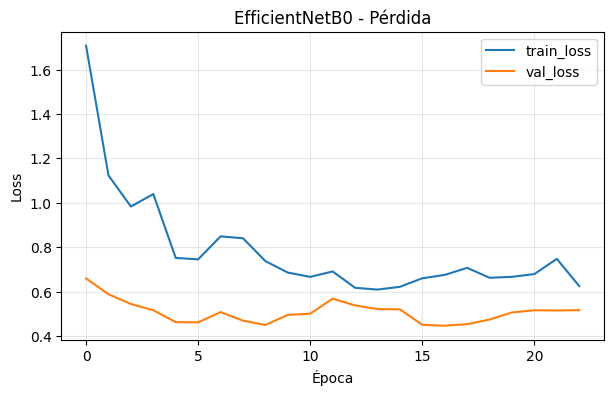

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(history_efficientnet_df["loss"], label="train_loss")
plt.plot(history_efficientnet_df["val_loss"], label="val_loss")
plt.title("EfficientNetB0 - Pérdida")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(figures_path / "efficientnetb0_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

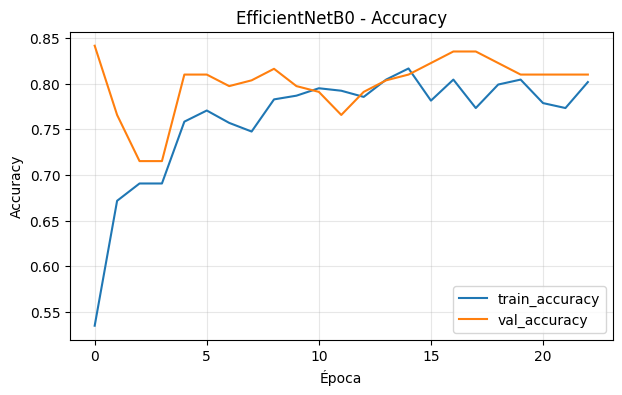

In [13]:
plt.figure(figsize=(7, 4))
plt.plot(history_efficientnet_df["accuracy"], label="train_accuracy")
plt.plot(history_efficientnet_df["val_accuracy"], label="val_accuracy")
plt.title("EfficientNetB0 - Accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(figures_path / "efficientnetb0_accuracy_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Evaluación en el conjunto de test

El conjunto de test se utiliza únicamente al final del entrenamiento. Se evalúa el mejor modelo guardado durante el fine-tuning para obtener una estimación final de rendimiento.

In [14]:
best_efficientnet_model = tf.keras.models.load_model(efficientnet_finetune_checkpoint_path)

test_loss, test_accuracy = best_efficientnet_model.evaluate(test_gen, verbose=1)

print("Test loss EfficientNetB0:", test_loss)
print("Test accuracy EfficientNetB0:", test_accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 141ms/step - accuracy: 0.8805 - loss: 0.3291
Test loss EfficientNetB0: 0.3291165232658386
Test accuracy EfficientNetB0: 0.8805031180381775


## 10. Métricas por clase

Se calculan precision, recall y F1-score para cada clase. Estas métricas son especialmente importantes porque el dataset está desbalanceado y la accuracy por sí sola puede resultar insuficiente.

Se prestará especial atención al comportamiento de la clase `malignant`, ya que los falsos negativos en esta clase son los errores más críticos.

In [15]:
test_gen.reset()

y_prob = best_efficientnet_model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_gen.classes

idx_to_class = {
    v: k for k, v in test_gen.class_indices.items()
}

target_names = [
    idx_to_class[i]
    for i in range(len(idx_to_class))
]

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=target_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

display(report_df)

report_df.to_csv(metrics_path / "efficientnetb0_classification_report.csv")

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 305ms/step


,precision,recall,f1-score,support
benign,0.466667,0.875000,0.608696,16.000000
malignant,0.987179,0.939024,0.962500,82.000000
normal,0.960784,0.803279,0.875000,61.000000
accuracy,0.880503,0.880503,0.880503,0.880503
macro avg,0.804877,0.872434,0.815399,159.000000
weighted avg,0.924674,0.880503,0.893328,159.000000


## 11. Métricas resumen

Se calculan métricas globales del modelo, incluyendo accuracy, macro precision, macro recall, macro F1-score y weighted F1-score.

El macro F1-score es una métrica relevante en este problema porque otorga el mismo peso a todas las clases, independientemente del número de muestras de cada una.

In [16]:
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

summary_metrics = pd.DataFrame({
    "model": ["EfficientNetB0"],
    "test_loss": [test_loss],
    "test_accuracy": [accuracy_score(y_true, y_pred)],
    "macro_precision": [macro_precision],
    "macro_recall": [macro_recall],
    "macro_f1": [macro_f1],
    "weighted_precision": [weighted_precision],
    "weighted_recall": [weighted_recall],
    "weighted_f1": [weighted_f1]
})

display(summary_metrics)

summary_metrics.to_csv(metrics_path / "efficientnetb0_summary_metrics.csv", index=False)

,model,test_loss,test_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,EfficientNetB0,0.329117,0.880503,0.804877,0.872434,0.815399,0.924674,0.880503,0.893328


## 12. Matriz de confusión

Se genera la matriz de confusión para analizar qué clases se confunden entre sí.

En este problema, los errores más relevantes son los casos `malignant` clasificados como `normal`, ya que representan falsos negativos clínicamente críticos.

In [17]:
cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=target_names,
    columns=target_names
)

display(cm_df)

cm_df.to_csv(metrics_path / "efficientnetb0_confusion_matrix.csv")

,benign,malignant,normal
benign,14,1,1
malignant,4,77,1
normal,12,0,49


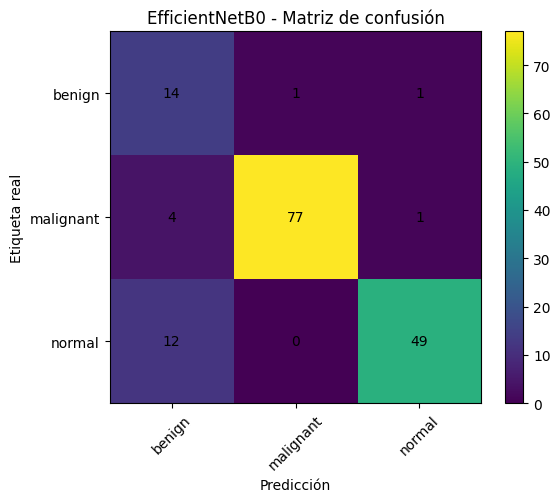

In [18]:
plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("EfficientNetB0 - Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")

plt.xticks(
    ticks=np.arange(len(target_names)),
    labels=target_names,
    rotation=45
)

plt.yticks(
    ticks=np.arange(len(target_names)),
    labels=target_names
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.savefig(figures_path / "efficientnetb0_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Distribución de predicciones

Se analiza cuántas imágenes han sido asignadas a cada clase por el modelo. Esta comprobación permite verificar que EfficientNetB0 predice las tres categorías y no colapsa hacia una única clase.

In [19]:
predicted_class_counts = pd.Series(
    [idx_to_class[i] for i in y_pred]
).value_counts()

print("Distribución de predicciones EfficientNetB0:")
print(predicted_class_counts)

Distribución de predicciones EfficientNetB0:
malignant    78
normal       51
benign       30
Name: count, dtype: int64


In [20]:
probabilities_summary = pd.DataFrame(
    y_prob,
    columns=[idx_to_class[i] for i in range(len(idx_to_class))]
).describe()

display(probabilities_summary)

probabilities_summary.to_csv(metrics_path / "efficientnetb0_probabilities_summary.csv")

,benign,malignant,normal
count,159.000000,159.000000,159.000000
mean,0.223968,0.478299,0.297733
std,0.294413,0.480904,0.360252
min,0.000009,0.000002,0.000001
25%,0.001188,0.000283,0.000450
50%,0.053176,0.264773,0.073190
75%,0.370498,0.998090,0.660569
max,0.977649,0.999986,0.990760


## 14. Guardado de predicciones

Se guarda un archivo con la clase real, la clase predicha, la confianza del modelo y las probabilidades asociadas a cada clase para todas las imágenes del conjunto de test.

Este archivo será utilizado posteriormente para comparar modelos y analizar errores de clasificación.

In [21]:
predictions_df = test_df.copy().reset_index(drop=True)

predictions_df["true_class"] = [
    idx_to_class[i]
    for i in y_true
]

predictions_df["pred_class"] = [
    idx_to_class[i]
    for i in y_pred
]

predictions_df["confidence"] = np.max(y_prob, axis=1)

predictions_df["correct"] = (
    predictions_df["true_class"] == predictions_df["pred_class"]
)

for class_name, class_idx in test_gen.class_indices.items():
    predictions_df[f"prob_{class_name}"] = y_prob[:, class_idx]

predictions_df.to_csv(metrics_path / "efficientnetb0_test_predictions.csv", index=False)

display(predictions_df.head())

,path,filename,original_class,class,width,height,mode,file_hash,true_class,pred_class,confidence,correct,prob_benign,prob_malignant,prob_normal
0,C:\Users\Usuario\.cache\kagglehub\datasets\adi...,Malignant case (212).jpg,Malignant cases,malignant,801,512,RGB,9a7fc962468f99fd5b06c12eb66fdacb,malignant,malignant,0.998680,True,0.000796,0.998680,0.000524
1,C:\Users\Usuario\.cache\kagglehub\datasets\adi...,Malignant case (519).jpg,Malignant cases,malignant,512,512,RGB,5912a5ce65ed6fc6bcba39272d363d83,malignant,malignant,0.996503,True,0.001340,0.996503,0.002156
2,C:\Users\Usuario\.cache\kagglehub\datasets\adi...,Normal case (399).jpg,Normal cases,normal,512,512,RGB,f7f5f6f93bf2beb10f9ff386ad5a6c3e,normal,normal,0.698823,True,0.300884,0.000292,0.698823
3,C:\Users\Usuario\.cache\kagglehub\datasets\adi...,Malignant case (266).jpg,Malignant cases,malignant,512,512,RGB,cc27e08e8172e2123ad240c6db095ce8,malignant,malignant,0.994301,True,0.005137,0.994301,0.000562
4,C:\Users\Usuario\.cache\kagglehub\datasets\adi...,Normal case (173).jpg,Normal cases,normal,512,512,RGB,17ffe48de6e6dee58a0ca1d81b9d9c6c,normal,benign,0.810772,False,0.810772,0.001067,0.188161


## 15. Análisis básico de errores

Se identifican las imágenes mal clasificadas por EfficientNetB0. En este notebook solo se realiza una inspección inicial, ya que el análisis comparativo detallado se llevará a cabo en el notebook final de comparación de modelos.

In [22]:
errors_df = predictions_df[~predictions_df["correct"]].copy()

print("Número de errores en test:", len(errors_df))

display(
    errors_df[
        ["filename", "true_class", "pred_class", "confidence", "path"]
    ].head(20)
)

Número de errores en test: 19


,filename,true_class,pred_class,confidence,path
4,Normal case (173).jpg,normal,benign,0.810772,C:\Users\Usuario\.cache\kagglehub\datasets\adi...
5,Normal case (13).jpg,normal,benign,0.588648,C:\Users\Usuario\.cache\kagglehub\datasets\adi...
12,Bengin case (120).jpg,benign,normal,0.556510,C:\Users\Usuario\.cache\kagglehub\datasets\adi...
14,Bengin case (52).jpg,benign,malignant,0.603854,C:\Users\Usuario\.cache\kagglehub\datasets\adi...
18,Normal case (170).jpg,normal,benign,0.851957,C:\Users\Usuario\.cache\kagglehub\datasets\adi...
19,Normal case (28).jpg,normal,benign,0.601860,C:\Users\Usuario\.cache\kagglehub\datasets\adi...
21,Malignant case (364).jpg,malignant,benign,0.555887,C:\Users\Usuario\.cache\kagglehub\datasets\adi...
22,Normal case (169).jpg,normal,benign,0.967963,C:\Users\Usuario\.cache\kagglehub\datasets\adi...
45,Normal case (157).jpg,normal,benign,0.850126,C:\Users\Usuario\.cache\kagglehub\datasets\adi...
65,Malignant case (36).jpg,malignant,benign,0.698511,C:\Users\Usuario\.cache\kagglehub\datasets\adi...


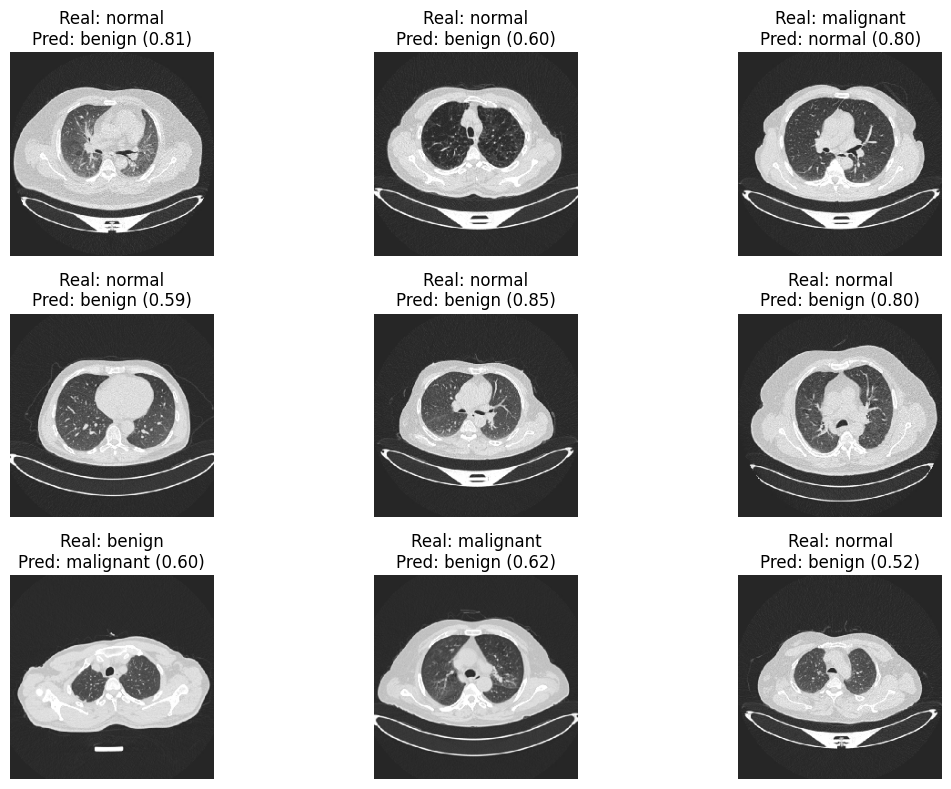

In [23]:
if len(errors_df) > 0:
    sample_errors = errors_df.sample(
        n=min(9, len(errors_df)),
        random_state=SEED
    )

    plt.figure(figsize=(12, 8))

    for i, (_, row) in enumerate(sample_errors.iterrows()):
        img = tf.keras.utils.load_img(
            row["path"],
            target_size=IMG_SIZE
        )

        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.title(
            f"Real: {row['true_class']}\n"
            f"Pred: {row['pred_class']} ({row['confidence']:.2f})"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(figures_path / "efficientnetb0_error_examples.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No se encontraron errores de clasificación en test.")

### Comentario breve sobre los resultados

EfficientNetB0 obtiene un rendimiento sólido y predice las tres clases del problema. El modelo mejora claramente respecto al baseline CNN entrenado desde cero y será comparado posteriormente con MobileNetV2 y ResNet50 en el notebook de comparación global.

La interpretación detallada de sus métricas se realizará junto con el resto de modelos.

## 16. Conclusión del notebook

En este notebook se ha entrenado EfficientNetB0 mediante transfer learning siguiendo un esquema de dos fases: entrenamiento de la cabeza clasificadora y fine-tuning parcial de la red.

El modelo se ha evaluado sobre el conjunto de test y se han guardado las métricas, matriz de confusión, curvas de entrenamiento y predicciones individuales.

Estos resultados se utilizarán posteriormente en el notebook de comparación global junto con MobileNetV2 y ResNet50.